In [2]:
import os
from os.path import join
import numpy as np
import pyntbci


In [3]:
wd = r'C:\Users\Radovan\OneDrive\Radboud\Studentships\Jordy Thielen\root'
os.chdir(wd)
data_dir = join(wd, "data")
experiment_dir = join(data_dir, "experiment")
files_dir = join(experiment_dir, 'files')
sourcedata_dir = join(experiment_dir, 'sourcedata')
derivatives_dir = join(join(experiment_dir, 'derivatives'))
os.chdir(wd)
data_dir = experiment_dir

In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

#data_dir = os.path.join(os.path.expanduser("~"), "data", "cvep_covert", "experiment")
#npz_data = np.load(file_path)
#subjects = ["VPpdia", "VPpdib"]
subjects = ["VPpdia","VPpdib", "VPpdic", "VPpdid", "VPpdie", "VPpdif", "VPpdig", "VPpdih", "VPpdii", "VPpdij",
            "VPpdik", "VPpdil", "VPpdim", "VPpdin", "VPpdio", "VPpdip", "VPpdiq", "VPpdir", "VPpdis", "VPpdit",
            "VPpdiu", "VPpdiv", "VPpdiw", "VPpdix", "VPpdiy", "VPpdiz", "VPpdiza", "VPpdizb", "VPpdizc"]
session = "S001"
tasks = ["overt", "covert"]



In [55]:
task = 'covert'
event = "dur"
onset_event = True
encoding_length = 0.3
ensemble = True
n_folds = 4
segments = np.linspace(5, 80, 16, dtype=int)*0.250
n_segments = segments.size
# Loop participants
accuracy = np.zeros((len(subjects), n_folds, n_segments))

for i_subject, subject in enumerate(subjects):
    print(f"{subject}", end="\t")

    # Load data
    file_dir = os.path.join(derivatives_dir, 'preprocessed', "cvep", f"sub-{subject}")
    fn = os.path.join(file_dir, f"sub-{subject}_task-{task}_cvep_64_noica.npz")
    tmp = np.load(fn)
    fs = int(tmp["fs"])
    X = tmp["X"]
    y = tmp["y"]
    V = tmp["V"]
    
    # Cross-validation
    folds = np.repeat(np.arange(n_folds), int(X.shape[0] / n_folds))
    for i_fold in range(n_folds):
        # Split data to train and test set
        X_trn, y_trn = X[folds != i_fold, :, :], y[folds != i_fold]
        X_tst, y_tst = X[folds == i_fold, :, :], y[folds == i_fold]

        # Train classifier
        rcca = pyntbci.classifiers.rCCA(stimulus=V, fs=fs, event=event, encoding_length=encoding_length,
                                        onset_event=onset_event, ensemble=ensemble)
        rcca.fit(X_trn, y_trn)

        # Loop segments
        for i_segment in range(n_segments):
        # Apply classifier
            yh_tst = rcca.predict(X_tst[:, :, :int(fs * segments[i_segment])])

            # Compute accuracy
            accuracy[i_subject, i_fold, i_segment] = np.mean(yh_tst == y_tst)



VPpdia	VPpdib	VPpdic	VPpdid	VPpdie	VPpdif	VPpdig	VPpdih	VPpdii	VPpdij	VPpdik	VPpdil	VPpdim	VPpdin	VPpdio	VPpdip	VPpdiq	VPpdir	VPpdis	VPpdit	VPpdiu	VPpdiv	VPpdiw	VPpdix	VPpdiy	VPpdiz	VPpdiza	VPpdizb	VPpdizc	

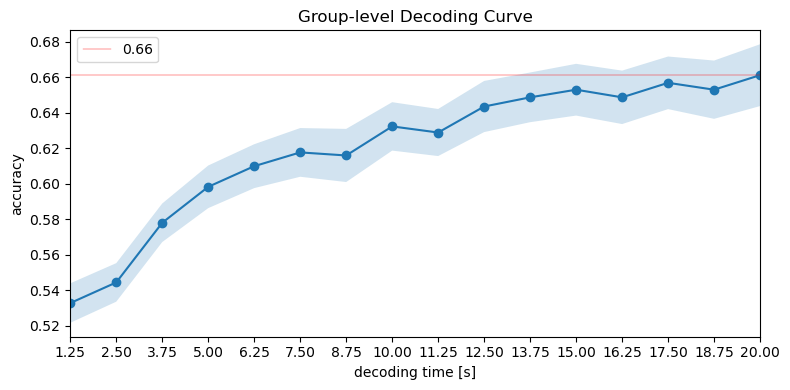

In [68]:
# 1) Subject‐level mean across folds -> (n_subjects, n_segments)
sub_avg = accuracy.mean(axis=1)

# 2) Group mean & SE across subjects -> (n_segments,)
group_avg = sub_avg.mean(axis=0)
group_se  = sub_avg.std(axis=0, ddof=1) / np.sqrt(sub_avg.shape[0])

# Plot decoding curve
plt.figure(figsize=(8, 4))
plt.plot(segments, group_avg, marker='o', linestyle='-')
plt.fill_between(segments, group_avg + group_se, group_avg - group_se, alpha=0.2)
plt.xlabel('decoding time [s]')
plt.ylabel('accuracy')
plt.title('Group‐level Decoding Curve')
plt.axhline(group_avg[-1], color = 'red', alpha = 1,
             linewidth = 0.3, label = f'{group_avg[-1]:.2f}')
# Decimate x-axis to 16 ticks between min and max segment
ticks = np.linspace(5, 80, 16, dtype=int)*0.250
plt.xticks(ticks)
plt.xlim(segments.min(), segments.max())
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
## Photo-ready saving
manuscript_dir = r'C:\Users\Radovan\OneDrive\Radboud\Studentships\Jordy Thielen\Manuscript\data'
m_ica_dir = join(manuscript_dir, 'ica')
m_noica_dir = join(manuscript_dir, 'noica')
save_path = os.path.join(m_noica_dir, "covert_lda_cvep_decC_64_noica.npz")

n_subjects = accuracy.shape[0]
sub_means = accuracy.mean(axis=1)
group_mean = sub_means.mean(axis=0)
sem_sub    = sub_means.std(axis=0, ddof=1)/ np.sqrt(n_subjects)

# pack results
group_results = {
    'time_window'     : segments,
    'mean_accuracy'   : group_mean,
    'standard_error'  : sem_sub
}


np.savez(
    save_path,
    epoch_bins=group_results['time_window'],
    mean_accuracies=group_results['mean_accuracy'],
    se_accuracies=group_results['standard_error']
)

print(f"results saved to {save_path}")

results saved to C:\Users\Radovan\OneDrive\Radboud\Studentships\Jordy Thielen\Manuscript\data\noica\covert_lda_cvep_decC_64_noica.npz


In [26]:

event = "dur"
onset_event = True
encoding_length = 0.3
ensemble = True
n_folds = 4
n_classes = 2
trialtime = 20  # limit trials to a certain duration in seconds
intertrialtime = 1.0  # ITI in seconds for computing ITR
n_samples = int(trialtime * fs)
segmenttime = 0.1  # step size of the decoding curve in seconds
segments = np.arange(segmenttime, trialtime, segmenttime)
n_segments = segments.size
# Loop folds
accuracy = np.zeros((n_folds, n_segments))
for i_fold in range(n_folds):

    # Split data to train and test set
    X_trn, y_trn = X[folds != i_fold, :, :n_samples], y[folds != i_fold]
    X_tst, y_tst = X[folds == i_fold, :, :n_samples], y[folds == i_fold]

    # Setup classifier
    rcca = pyntbci.classifiers.rCCA(stimulus=V, fs=fs, event="duration", encoding_length=0.3, onset_event=True)

    # Train classifier
    rcca.fit(X_trn, y_trn)

    # Loop segments
    for i_segment in range(n_segments):
        # Apply classifier
        yh_tst = rcca.predict(X_tst[:, :, :int(fs * segments[i_segment])])

        # Compute accuracy
        accuracy[i_fold, i_segment] = np.mean(yh_tst == y_tst)

# Compute ITR
time = np.tile(segments[np.newaxis, :], (n_folds, 1))
itr = pyntbci.utilities.itr(n_classes, accuracy, time + intertrialtime)




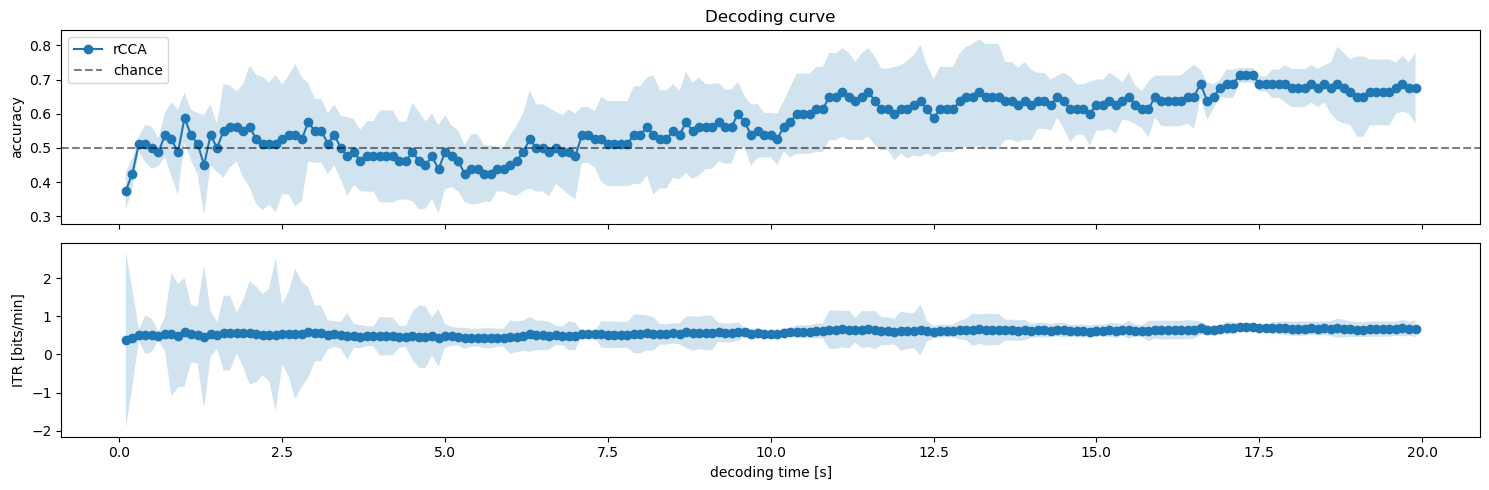

In [28]:
import matplotlib.pyplot as plt
# Plot results
fig, ax = plt.subplots(2, 1, figsize=(15, 5), sharex=True)
avg = accuracy.mean(axis=0)
std = accuracy.std(axis=0)
ax[0].plot(segments, avg, linestyle='-', marker='o', label="rCCA")
ax[0].fill_between(segments, avg + std, avg - std, alpha=0.2, label="_rCCA")
ax[0].axhline(1 / n_classes, color="k", linestyle="--", alpha=0.5, label="chance")
#avg = itr.mean(axis=0)
std = itr.std(axis=0)
ax[1].plot(segments, avg, linestyle='-', marker='o', label="rCCA")
ax[1].fill_between(segments, avg + std, avg - std, alpha=0.2, label="_rCCA")
ax[1].set_xlabel("decoding time [s]")
ax[0].set_ylabel("accuracy")
ax[1].set_ylabel("ITR [bits/min]")
ax[0].legend()
ax[0].set_title("Decoding curve")
fig.tight_layout()

In [29]:
avg

array([0.375 , 0.425 , 0.5125, 0.5125, 0.5   , 0.4875, 0.5375, 0.525 ,
       0.4875, 0.5875, 0.5375, 0.5125, 0.45  , 0.5375, 0.5   , 0.55  ,
       0.5625, 0.5625, 0.55  , 0.5625, 0.525 , 0.5125, 0.5125, 0.5125,
       0.525 , 0.5375, 0.5375, 0.525 , 0.575 , 0.55  , 0.55  , 0.5125,
       0.5375, 0.5   , 0.475 , 0.4875, 0.4625, 0.475 , 0.475 , 0.475 ,
       0.475 , 0.475 , 0.4625, 0.4625, 0.4875, 0.4625, 0.45  , 0.475 ,
       0.4375, 0.4875, 0.475 , 0.4625, 0.425 , 0.4375, 0.4375, 0.425 ,
       0.425 , 0.4375, 0.4375, 0.45  , 0.4625, 0.4875, 0.525 , 0.5   ,
       0.5   , 0.4875, 0.5   , 0.4875, 0.4875, 0.475 , 0.5375, 0.5375,
       0.525 , 0.525 , 0.5125, 0.5125, 0.5125, 0.5125, 0.5375, 0.5375,
       0.5625, 0.5375, 0.525 , 0.525 , 0.55  , 0.5375, 0.575 , 0.55  ,
       0.5625, 0.5625, 0.5625, 0.575 , 0.5625, 0.5625, 0.6   , 0.575 ,
       0.5375, 0.55  , 0.5375, 0.5375, 0.525 , 0.5625, 0.575 , 0.6   ,
       0.6   , 0.6   , 0.6125, 0.6125, 0.65  , 0.65  , 0.6625, 0.65  ,
      

In [30]:
import os
import numpy as np
import pyntbci

# === PARAMETERS ===
#derivatives_dir = 
#results_dir     = 
#os.makedirs(results_dir, exist_ok=True)
#
#subjects = ["01", "02", "03", ...]  # list of subject IDs (without 'sub-')
#tasks    = ["A", "B", "C", ...]      # list of task labels

event            = "dur"
onset_event      = True
encoding_length  = 0.3
ensemble         = True
n_folds          = 4
n_classes        = 2
trialtime        = 20    # seconds
intertrialtime   = 1.0   # seconds
segmenttime      = 1.25   # step size in seconds

# Precompute segment time‐points
# (i.e. how much data we feed the classifier at each step)
# segments[k] == number of seconds of signal included at step k+1
# compute segment ends and count
segments   = np.arange(segmenttime, trialtime + 1e-10, segmenttime)
n_segments = segments.size

# prepare a container: (n_subjects, n_folds, n_segments)
n_subjects    = len(subjects)
accuracy_all  = np.zeros((n_subjects, n_folds, n_segments))
se_all        = np.zeros((n_subjects, n_segments))

for i_subject, subject in enumerate(subjects):
    print(f"Subject {subject} ({i_subject+1}/{n_subjects})")
    
    # load your data once per subject (or loop tasks here)
    fn = os.path.join(
        derivatives_dir, "preprocessed", "cvep",
        f"sub-{subject}",
        f"sub-{subject}_task-{task}_cvep_64_icaspace.npz"
    )
    tmp = np.load(fn)
    fs  = int(tmp["fs"])
    X   = tmp["X"][:, :, :int(trialtime * fs)]
    y   = tmp["y"]
    V   = tmp["V"]
    
    # build fold assignments
    folds = np.repeat(np.arange(n_folds), X.shape[0] // n_folds)

    # scratch array for this subject
    acc_sub = np.zeros((n_folds, n_segments))

    for i_fold in range(n_folds):
        X_trn = X[folds != i_fold]
        y_trn = y[folds != i_fold]
        X_tst = X[folds == i_fold]
        y_tst = y[folds == i_fold]

        # train
        clf = pyntbci.classifiers.rCCA(
            stimulus=V, fs=fs,
            event="dur", encoding_length=0.3, onset_event=True
        )
        clf.fit(X_trn, y_trn)

        # test at each segment
        for k, seg in enumerate(segments):
            npt = int(seg * fs)
            yh = clf.predict(X_tst[:, :, :npt])
            acc_sub[i_fold, k] = np.mean(yh == y_tst)

    # store fold‐wise accuracies
    accuracy_all[i_subject] = acc_sub

    # compute standard error across folds for this subject
    se_all[i_subject] = acc_sub.std(axis=0, ddof=1) / np.sqrt(n_folds)

# now accuracy_all[s] gives you the 4×n_segments matrix for subject s
# and se_all[s] the 1×n_segments of standard errors


        # --- save results ---
        #out_fn = os.path.join(
        #    results_dir,
        #    f"sub-{subject}_task-{task}_results.npz"
        #)
        #np.savez_compressed(
        #    out_fn,
        #    time=segments,
        #    accuracy=accuracy,
        #    se=se
        #)
        #print(f"saved → {out_fn}")

print("All done.")


Subject VPpdia (1/29)
Subject VPpdib (2/29)
Subject VPpdic (3/29)
Subject VPpdid (4/29)
Subject VPpdie (5/29)
Subject VPpdif (6/29)
Subject VPpdig (7/29)
Subject VPpdih (8/29)
Subject VPpdii (9/29)
Subject VPpdij (10/29)
Subject VPpdik (11/29)
Subject VPpdil (12/29)
Subject VPpdim (13/29)
Subject VPpdin (14/29)
Subject VPpdio (15/29)
Subject VPpdip (16/29)
Subject VPpdiq (17/29)
Subject VPpdir (18/29)
Subject VPpdis (19/29)
Subject VPpdit (20/29)
Subject VPpdiu (21/29)
Subject VPpdiv (22/29)
Subject VPpdiw (23/29)
Subject VPpdix (24/29)
Subject VPpdiy (25/29)
Subject VPpdiz (26/29)
Subject VPpdiza (27/29)
Subject VPpdizb (28/29)
Subject VPpdizc (29/29)
All done.


In [35]:
task

'covert'

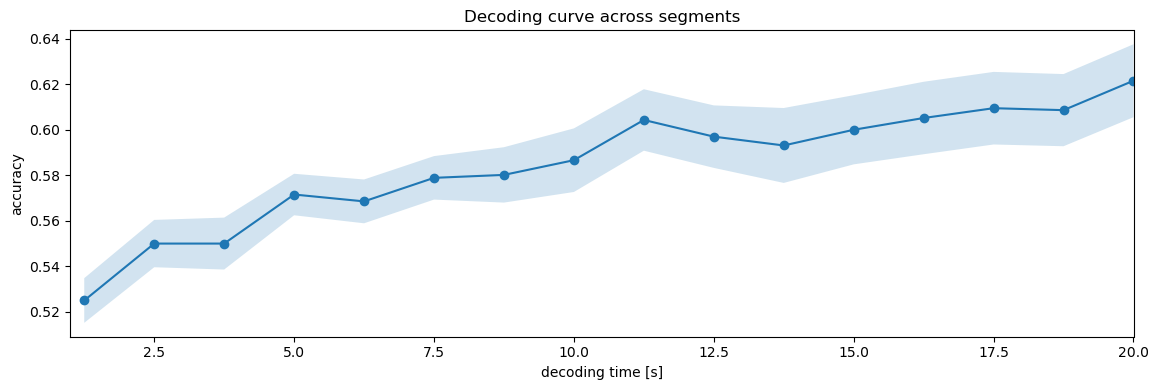

In [31]:
#data = np.load('group_accuracy.npz')
segments      = segments       # 1D array of segment end‐points (s)
accuracy_all  = accuracy_all      # shape (n_subjects, n_folds, n_segments)

# Compute per‐subject mean across folds, then group average & SE across subjects
sub_avg     = accuracy_all.mean(axis=1)  # (n_subjects, n_segments)
group_avg   = sub_avg.mean(axis=0)       # (n_segments,)
group_se    = sub_avg.std(axis=0, ddof=1) / np.sqrt(sub_avg.shape[0])

# Plot decoding curve
plt.figure(figsize=(11.69, 4))
plt.plot(segments, group_avg, linestyle='-', marker='o')
plt.fill_between(segments, group_avg + group_se, group_avg - group_se, alpha=0.2)
plt.xlabel('decoding time [s]')
plt.ylabel('accuracy')
plt.title('Decoding curve across segments')

# Decimate x‐axis to 16 ticks from 1 to 20 s
#ticks = np.linspace(1, 20, 16)
#plt.xticks(ticks)
plt.xlim(1, 20)

plt.tight_layout()
plt.show()

In [33]:
group_avg

array([0.525     , 0.55      , 0.55      , 0.57155172, 0.56853448,
       0.57887931, 0.58017241, 0.58663793, 0.60431034, 0.59698276,
       0.59310345, 0.6       , 0.60517241, 0.60948276, 0.60862069,
       0.62155172])